# Imports and helper functions

In [12]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import tensorflow as tf
import numpy as np
import cv2
import random

In [ ]:
GLOBAL_MODEL_IMG_SIZE = (112, 224)

img_paths = os.listdir('data/')
#open inputs.csv
df = pd.read_csv('inputs.csv')
df = df.sort_values(by='timestamp').reset_index(drop=True)
data = df.to_dict('records')
print(len(data))

for img in img_paths:
    if img[:-5] not in df['uuid'].values:
        print(f"Image {img} is not in the dataframe.")

to_remove = []
for record in data:
    if record['uuid'] + '.jpeg' not in img_paths:
        print(f"Record with uuid {record['uuid']} does not have a corresponding image.")
        print("Removed record from data.")
        to_remove.append(record)

for record in to_remove:
    data.remove(record)

1416
Record with uuid ee0e91a4-494a-11f1-83c5-16f63a1aa8c9 does not have a corresponding image.
Removed record from data.
Record with uuid ee12bf72-494a-11f1-83c5-16f63a1aa8c9 does not have a corresponding image.
Removed record from data.
Record with uuid ee2b4ea2-494a-11f1-83c5-16f63a1aa8c9 does not have a corresponding image.
Removed record from data.
Record with uuid ee31953c-494a-11f1-83c5-16f63a1aa8c9 does not have a corresponding image.
Removed record from data.
Record with uuid ee5960b2-494a-11f1-83c5-16f63a1aa8c9 does not have a corresponding image.
Removed record from data.
Record with uuid ee61b9ba-494a-11f1-83c5-16f63a1aa8c9 does not have a corresponding image.
Removed record from data.
Record with uuid ee669c78-494a-11f1-83c5-16f63a1aa8c9 does not have a corresponding image.
Removed record from data.
Record with uuid ee6c7e18-494a-11f1-83c5-16f63a1aa8c9 does not have a corresponding image.
Removed record from data.
Record with uuid ee72b904-494a-11f1-83c5-16f63a1aa8c9 does 

In [14]:
def imshow(img, size = None):
    if size is not None:
        img = cv2.resize(img, size)
    if type(img) == str:
        image = plt.imread('data/' + img)
        plt.imshow(image)
        plt.axis('off')
        plt.show()
    else:
        plt.imshow(img)
        plt.axis('off')
        plt.show()

def crop_image(img):
    imsize = img.shape
    cropped = img[imsize[0] // 2:, :]
    resized = cv2.resize(cropped, (GLOBAL_MODEL_IMG_SIZE[1], GLOBAL_MODEL_IMG_SIZE[0]))
    return resized

# for i in range(100,200,10):
#     imshow(crop_image(data[i]['uuid'] + '.jpeg'), size=(224, 112))
#     imshow(crop_image(data[i]['uuid'] + '.jpeg'), size=(112, 64))
#     imshow(crop_image(data[i]['uuid'] + '.jpeg'), size=(64, 32))

#  Generate streaks

Streak - series of inputs with less than 0.3 seconds between them
Filtered_frames - frames from streaks more than second long

In [15]:
streak_th = 0.3
seconds_th = 0.5
streaks = {}
current_streak = []
for i, datapoint in enumerate(data):
    timestamp = datetime.strptime(datapoint['timestamp'], '%Y-%m-%dT%H:%M:%S.%f')
    prev_timestamp = datetime.strptime(data[i-1]['timestamp'], '%Y-%m-%dT%H:%M:%S.%f') if i > 0 else None
    time_diff = timestamp - prev_timestamp if prev_timestamp is not None else None
    if time_diff is not None and time_diff.total_seconds() > streak_th:
        if current_streak:
            streaks[current_streak[0]['uuid']] = {"datapoints" : current_streak, "start_time": current_streak[0]['timestamp'], "end_time": current_streak[-1]['timestamp']}
            current_streak = []
        else:
            current_streak = [datapoint]
    else:
        current_streak.append(datapoint)

print(f"Found {len(streaks)} streaks of frames with less than {streak_th} seconds between them.")
filtered_streaks = {k: v for k, v in streaks.items() if datetime.strptime(v['end_time'], '%Y-%m-%dT%H:%M:%S.%f') - datetime.strptime(v['start_time'], '%Y-%m-%dT%H:%M:%S.%f') > timedelta(seconds=seconds_th)}
print(f"Found {len(filtered_streaks)} streaks of frames with more than {seconds_th} seconds in them.")

filtered_frames = [frame for streak in filtered_streaks.values() for frame in streak['datapoints'][:-5]]
print(f"Found {len(filtered_frames)} frames in the filtered streaks.")

Found 95 streaks of frames with less than 0.3 seconds between them.
Found 43 streaks of frames with more than 0.5 seconds in them.
Found 731 frames in the filtered streaks.


In [16]:
# Testing the quality of streaks by showing them frame by frame
# for i in filtered_streaks:
#     print(f"Streak {i} has {len(filtered_streaks[i]['datapoints'])} frames, from {filtered_streaks[i]['start_time']} to {filtered_streaks[i]['end_time']}.")

# for frame in filtered_streaks[list(filtered_streaks.keys())[7]]['datapoints']:
#     crop_image(frame['uuid'] + '.jpeg', show=True)

# Training

In [17]:
random.shuffle(filtered_frames)
train_data = filtered_frames[:int(0.8*len(filtered_frames))]
val_data = filtered_frames[int(0.8*len(filtered_frames)):int(0.9*len(filtered_frames))]
test_data = filtered_frames[int(0.9*len(filtered_frames)):]
print(f"Train data: {len(train_data)} frames, Val data: {len(val_data)} frames, Test data: {len(test_data)} frames.")

Train data: 584 frames, Val data: 73 frames, Test data: 74 frames.


In [18]:
def augment_image(img, label):
    # Random brightness ±20%
    img = tf.image.random_brightness(img, max_delta=0.2)
    
    def rescale(img):
        h, w = img.shape[:2]
        new_h, new_w = int(h * np.random.uniform(1, 1.1)), int(w * np.random.uniform(1, 1.1))
        resized = cv2.resize(img, (new_w, new_h))
        return resized[(new_h - h) // 2:(new_h - h) // 2 + h, (new_w - w) // 2:(new_w - w) // 2 + w].astype(np.float32)
    
    def tilt(img):
        img_np = img.numpy()
        angle = np.random.uniform(-3, 3)
        h, w = img_np.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        rotated = cv2.warpAffine(img_np, M, (w, h))
        return rescale(rotated)
    
    img = tf.py_function(tilt, [img], tf.float32)
    img.set_shape((GLOBAL_MODEL_IMG_SIZE[0], GLOBAL_MODEL_IMG_SIZE[1], 3))
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


def load_dataset(data, img_size=GLOBAL_MODEL_IMG_SIZE, batch_size=16, augment=False):
    paths = [d['uuid'] + '.jpeg' for d in data]
    labels = [[d['left_wheel'], d['right_wheel']] for d in data]

    def load_image(path, label):
        def _load(path):
            img = plt.imread('data/' + path.numpy().decode('utf-8'))  # RGB uint8
            img = crop_image(img)                                      # (32, 64, 3)
            img = img.astype(np.float32) / 255.0
            return img
        img = tf.py_function(_load, [path], tf.float32)
        img.set_shape((img_size[0], img_size[1], 3))
        return img, label

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        augment_times = 3
        original = dataset
        for _ in range(augment_times - 1):
            dataset = dataset.concatenate(
                original.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
            )
    dataset = dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [19]:
# Test a single sample outside the tf.data pipeline
sample_path = train_data[0]['uuid'] + '.jpeg'
img = plt.imread('data/' + sample_path)
print("dtype:", img.dtype)
print("shape:", img.shape)
print("min/max:", img.min(), img.max())

cropped = crop_image(img)
print("cropped shape:", cropped.shape)  # should be (GLOBAL_MODEL_IMG_SIZE[0], GLOBAL_MODEL_IMG_SIZE[1], 3)

dtype: uint8
shape: (224, 224, 3)
min/max: 0 255
cropped shape: (112, 224, 3)


In [ ]:
# Usage - augment only training data, not validation
train_ds = load_dataset(train_data, augment=True)
val_ds = load_dataset(val_data, augment=False)

base = tf.keras.applications.EfficientNetB0(include_top=False, pooling='avg', input_shape=(GLOBAL_MODEL_IMG_SIZE[0], GLOBAL_MODEL_IMG_SIZE[1], 3))
base.trainable = True
output = tf.keras.layers.Dense(2)(base.output)
model = tf.keras.Model(base.input, output)
model.compile(optimizer='adamW', loss=tf.keras.losses.Huber(), metrics=['mse', 'mae'])

model.fit(train_ds, validation_data=val_ds, epochs=100)

model.save('model.keras')

Epoch 1/100


5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 789ms/step - loss: 0.0063 - mae: 0.0911 - mse: 0.0127
Label: [[0.20000137 0.19999863]]
Prediction: [[0.18838628 0.08644901]]


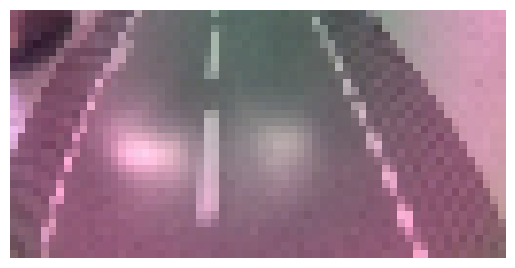

Label: [[0.13682353 0.26317647]]
Prediction: [[0.18673897 0.08346898]]


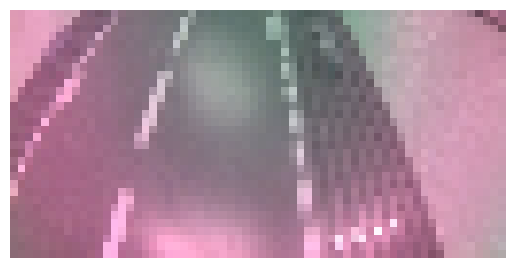

Label: [[0.11 0.29]]
Prediction: [[0.18005148 0.08040614]]


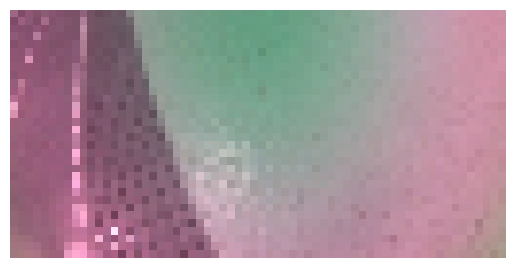

Label: [[0.20000137 0.19999863]]
Prediction: [[0.1902436  0.08855888]]


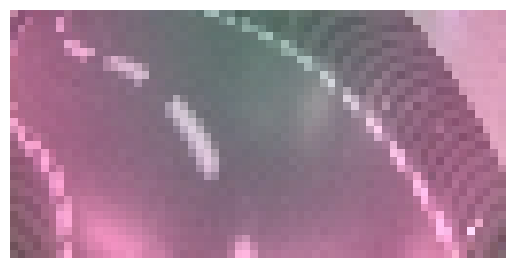

Label: [[0.11 0.29]]
Prediction: [[0.1789332  0.08228759]]


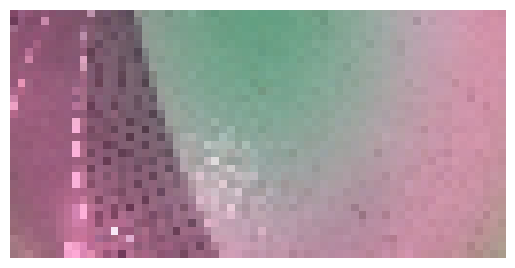

Label: [[0.11 0.29]]
Prediction: [[0.17819785 0.08622207]]


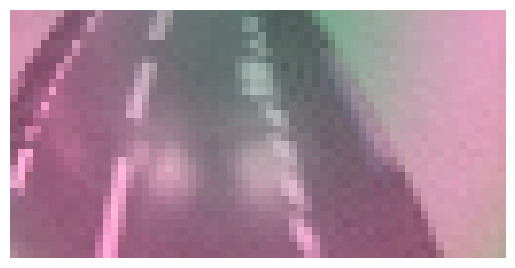

Label: [[0.20000137 0.19999863]]
Prediction: [[0.1840449  0.07884465]]


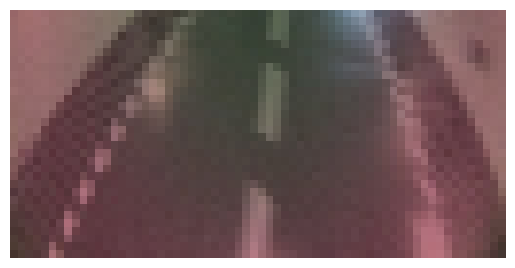

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18526036 0.07827102]]


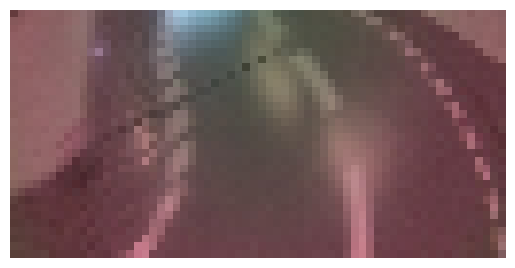

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18752047 0.08458087]]


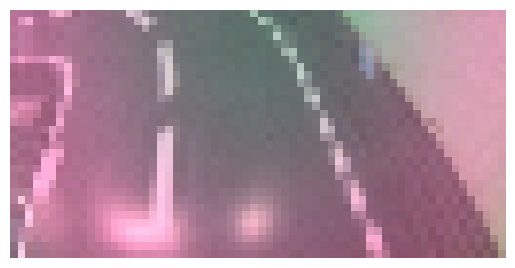

Label: [[0.11 0.29]]
Prediction: [[0.18313856 0.08325958]]


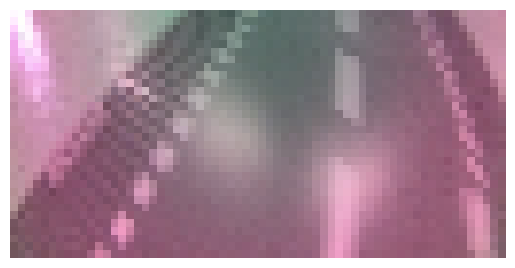

Label: [[0.20000137 0.19999863]]
Prediction: [[0.1872674  0.08159602]]


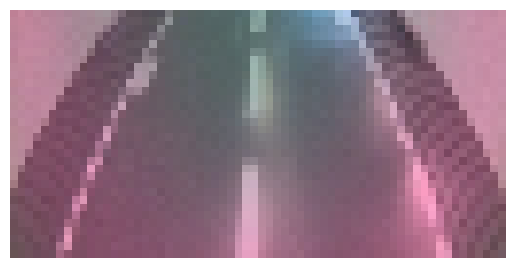

Label: [[0.11564706 0.28435293]]
Prediction: [[0.18765435 0.08425666]]


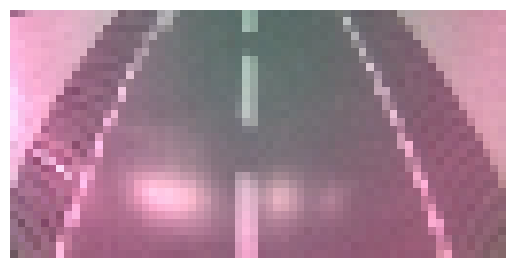

Label: [[0.11 0.29]]
Prediction: [[0.17965925 0.08094884]]


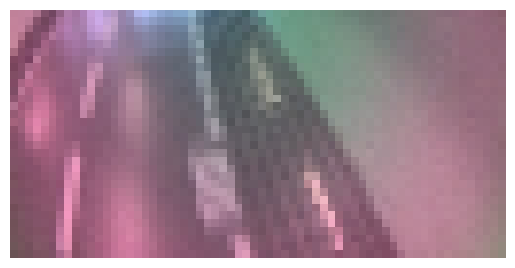

Label: [[0.17282353 0.22717647]]
Prediction: [[0.18287571 0.0789528 ]]


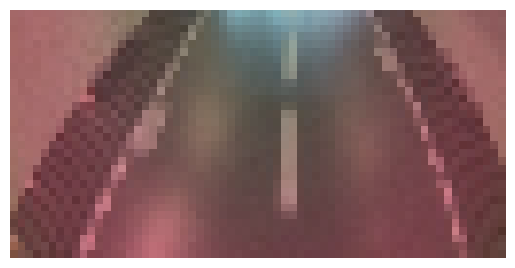

Label: [[0.20000137 0.19999863]]
Prediction: [[0.1902436  0.08855888]]


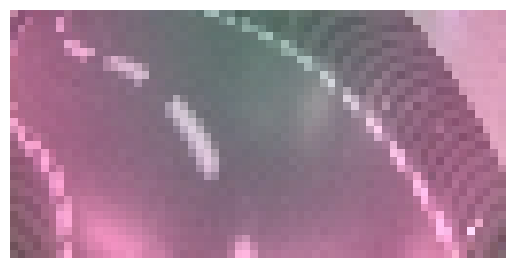

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18710798 0.08238039]]


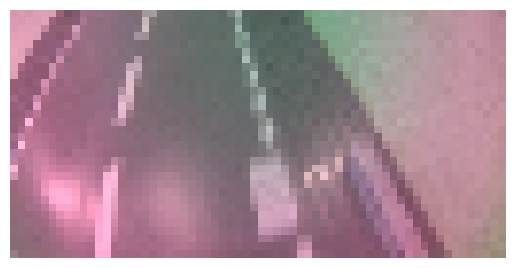

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18620667 0.07926649]]


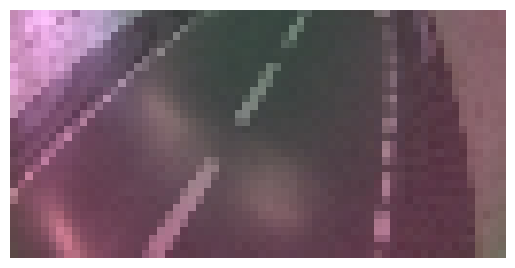

Label: [[0.29 0.11]]
Prediction: [[0.1896662  0.08672958]]


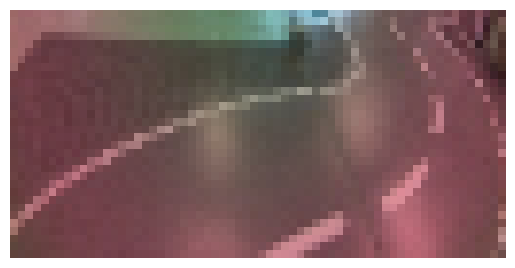

Label: [[0.12129412 0.2787059 ]]
Prediction: [[0.1862766  0.08311622]]


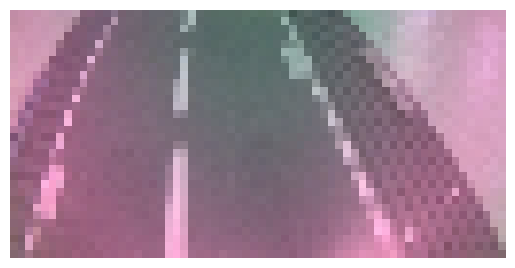

Label: [[0.11 0.29]]
Prediction: [[0.18412317 0.0854007 ]]


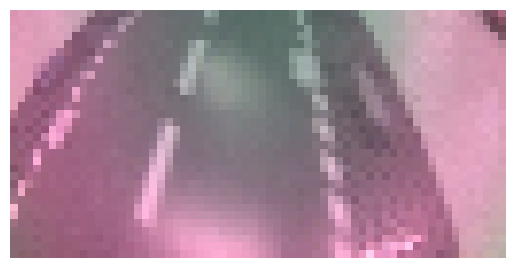

Label: [[0.11 0.29]]
Prediction: [[0.18211909 0.08094769]]


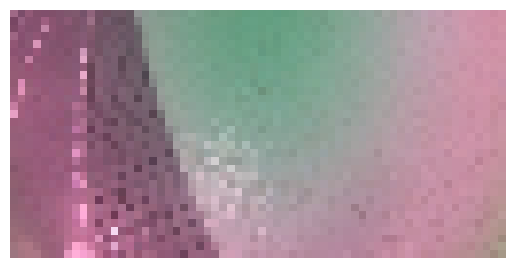

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18637818 0.08063596]]


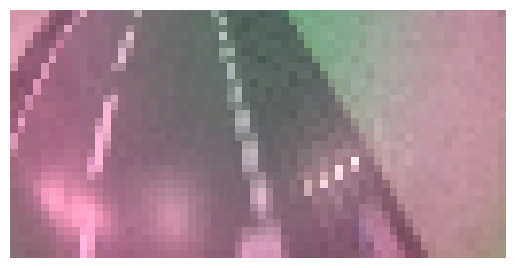

Label: [[0.14317647 0.25682354]]
Prediction: [[0.18530364 0.08648203]]


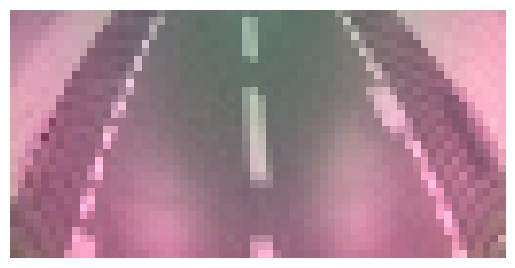

Label: [[0.20000137 0.19999863]]
Prediction: [[0.1859407  0.07895456]]


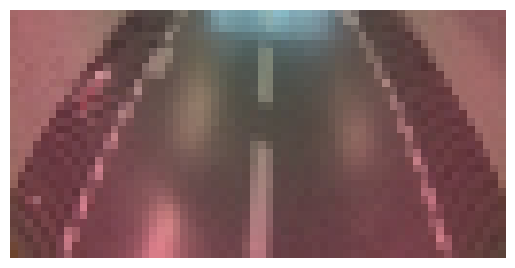

Label: [[0.11 0.29]]
Prediction: [[0.18693924 0.07929052]]


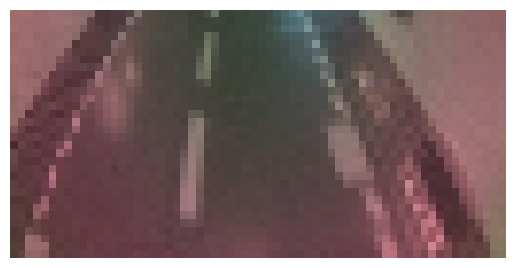

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18486243 0.0799697 ]]


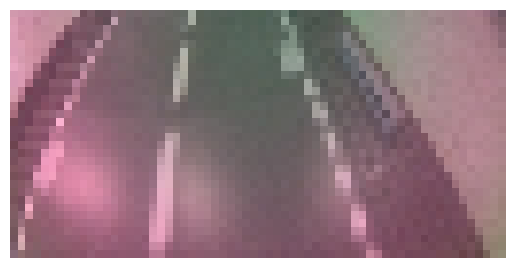

Label: [[0.11 0.29]]
Prediction: [[0.18279104 0.08266273]]


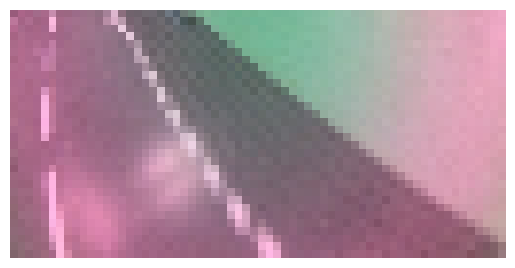

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18904845 0.08455836]]


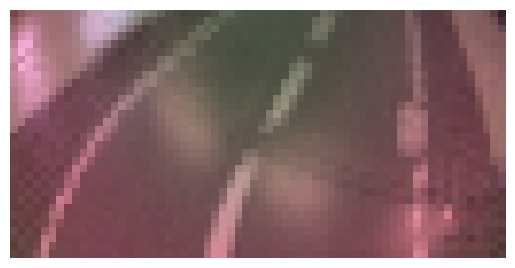

Label: [[0.11 0.29]]
Prediction: [[0.17749922 0.08400188]]


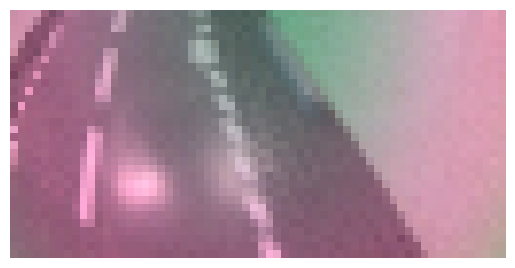

Label: [[0.27164707 0.12835294]]
Prediction: [[0.18447027 0.08467163]]


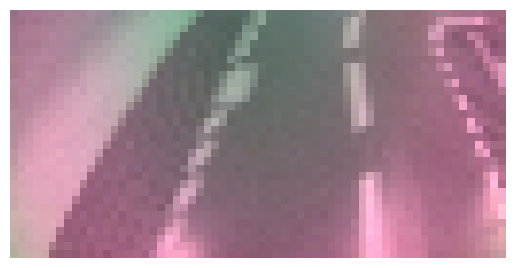

Label: [[0.18058823 0.21941176]]
Prediction: [[0.1885787  0.08398765]]


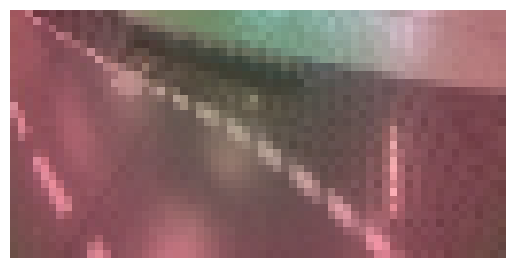

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18546025 0.0861457 ]]


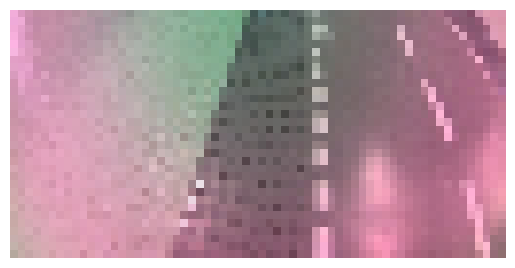

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18526325 0.0798638 ]]


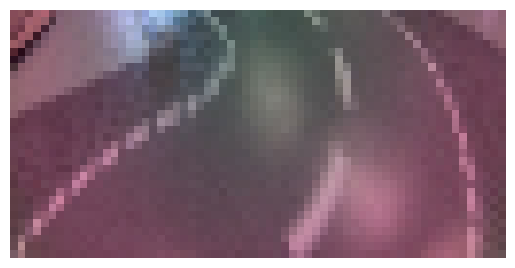

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18618655 0.07875057]]


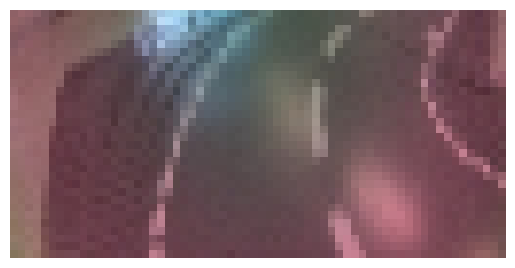

Label: [[0.20000137 0.19999863]]
Prediction: [[0.1873206  0.08395237]]


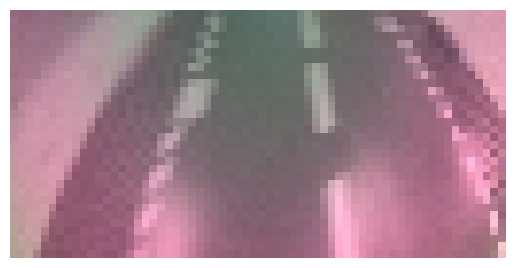

Label: [[4.4251165e-06 1.6784924e-06]]
Prediction: [[0.18359596 0.08040521]]


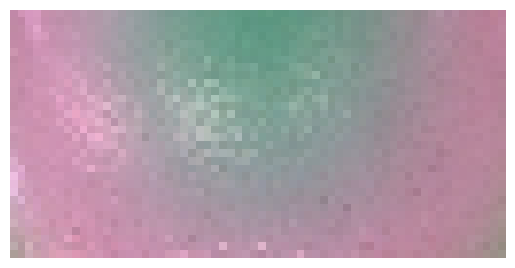

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18890232 0.08570783]]


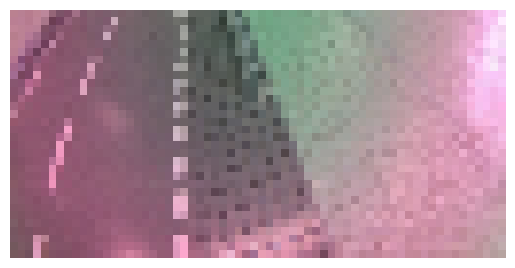

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18844414 0.08350348]]


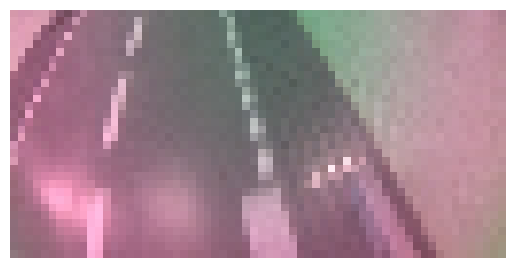

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18605742 0.07920592]]


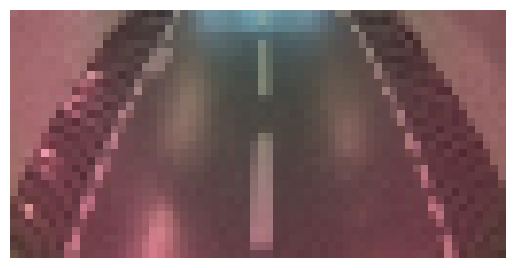

Label: [[0.11 0.29]]
Prediction: [[0.18236892 0.08409218]]


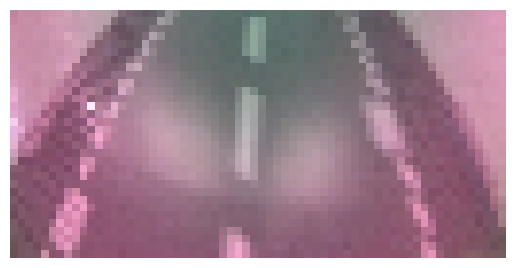

Label: [[0.11 0.29]]
Prediction: [[0.1885768  0.08611683]]


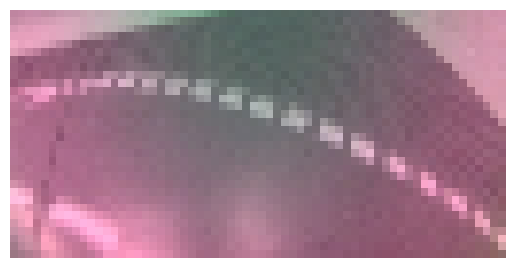

Label: [[0.29 0.11]]
Prediction: [[0.18348314 0.08113822]]


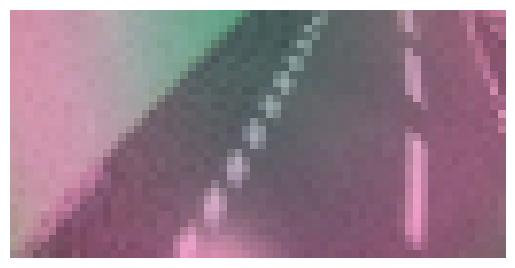

Label: [[0.11 0.29]]
Prediction: [[0.18954039 0.08538731]]


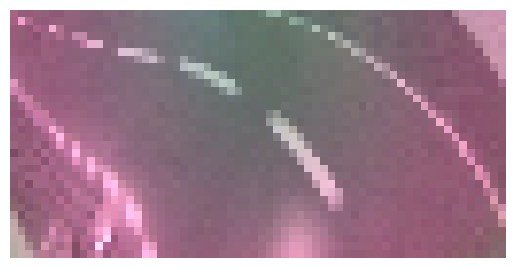

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18900757 0.08456612]]


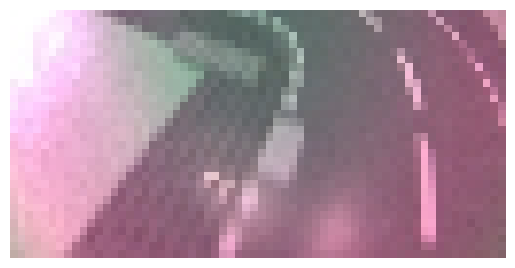

Label: [[0.29 0.11]]
Prediction: [[0.18591863 0.07914762]]


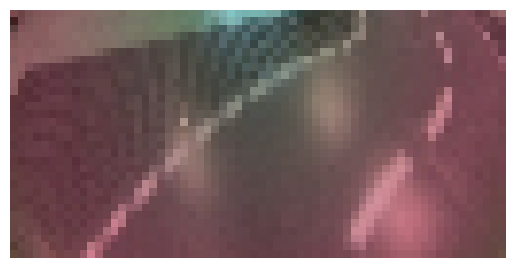

Label: [[0.11 0.29]]
Prediction: [[0.17386013 0.08748394]]


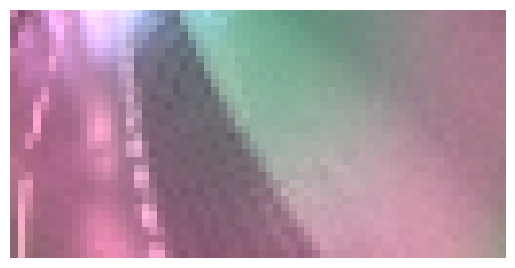

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18876351 0.0841313 ]]


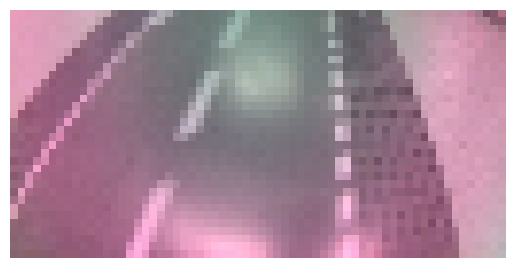

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18943435 0.083482  ]]


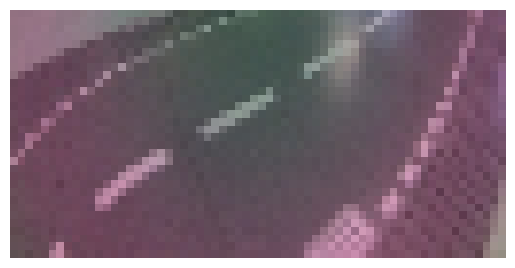

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18942636 0.08677668]]


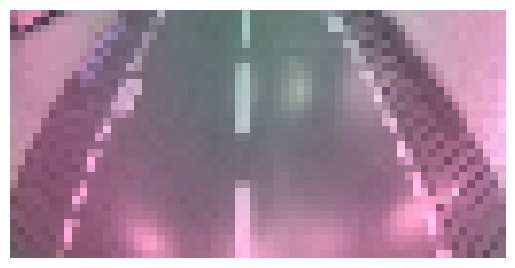

Label: [[0.29 0.11]]
Prediction: [[0.18818781 0.08339362]]


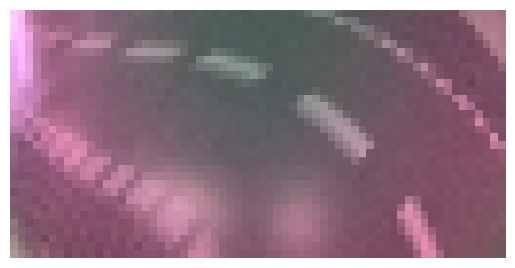

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18505609 0.07825592]]


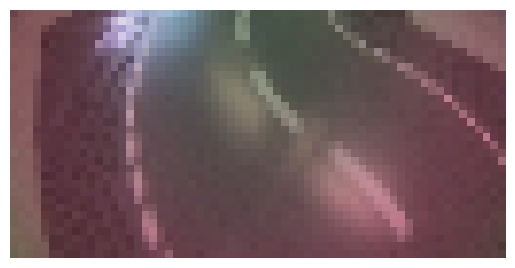

Label: [[0.11 0.29]]
Prediction: [[0.1854802 0.0816961]]


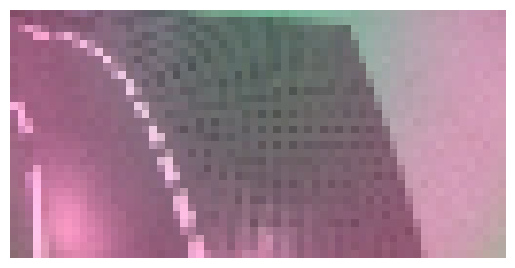

Label: [[0.29 0.11]]
Prediction: [[0.18336911 0.07917081]]


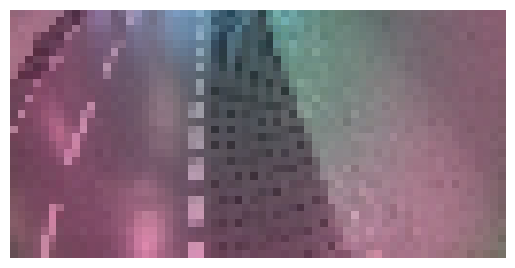

Label: [[0.11 0.29]]
Prediction: [[0.18339863 0.08311211]]


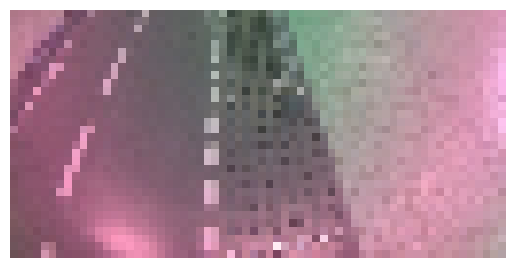

Label: [[0.20000137 0.19999863]]
Prediction: [[0.19065894 0.08812523]]


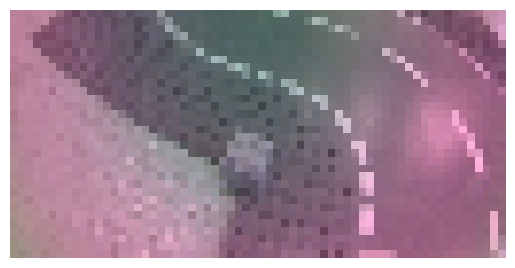

Label: [[0.15588236 0.24411765]]
Prediction: [[0.18911813 0.08380257]]


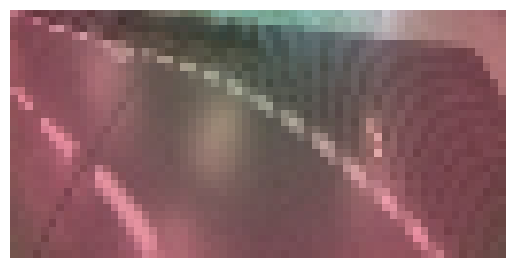

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18437189 0.07908063]]


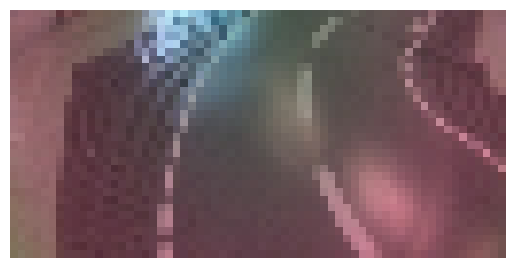

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18908086 0.08373868]]


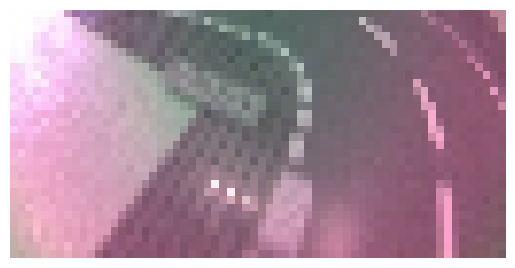

Label: [[0.14670588 0.2532941 ]]
Prediction: [[0.18837278 0.0828669 ]]


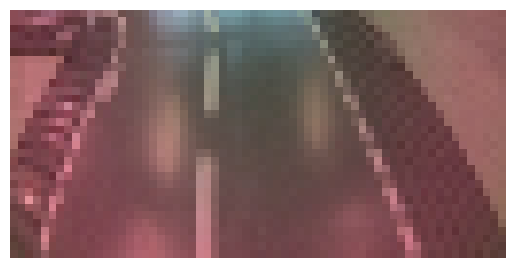

Label: [[0.11 0.29]]
Prediction: [[0.17835686 0.08448972]]


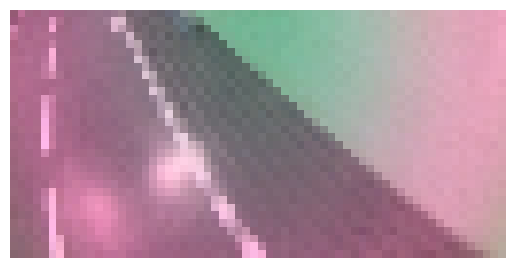

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18814379 0.08196875]]


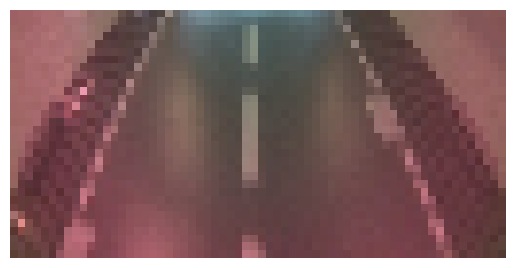

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18226424 0.08739724]]


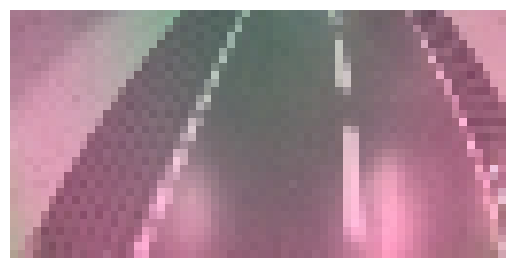

Label: [[0.12129412 0.2787059 ]]
Prediction: [[0.18721008 0.08398904]]


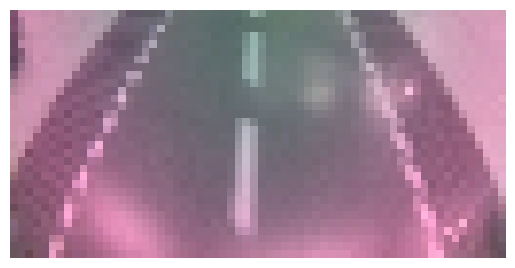

Label: [[0.29 0.11]]
Prediction: [[0.1822694  0.08634719]]


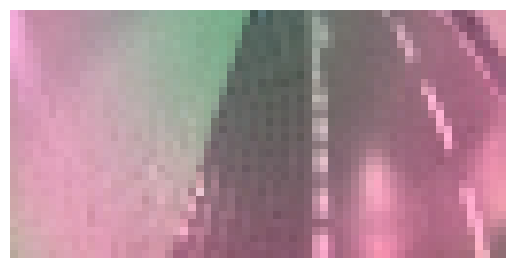

Label: [[0.29 0.11]]
Prediction: [[0.1892708  0.08406402]]


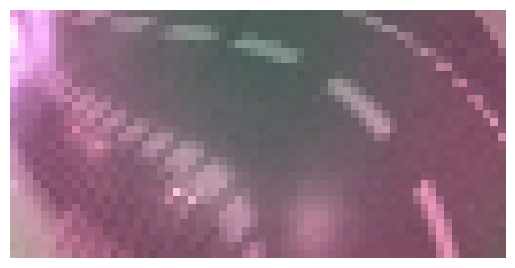

Label: [[0.11 0.29]]
Prediction: [[0.18402854 0.08656898]]


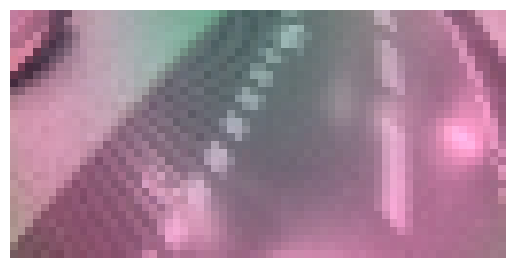

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18975572 0.08429307]]


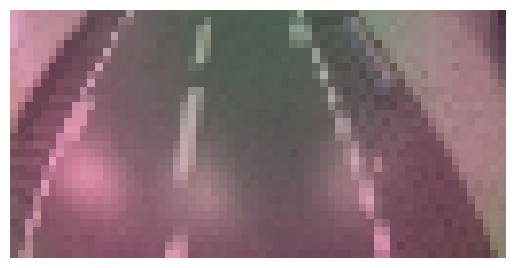

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18912774 0.08540363]]


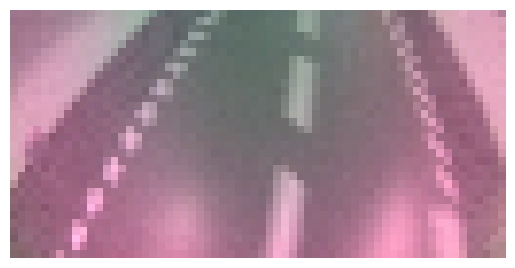

Label: [[0.20000137 0.19999863]]
Prediction: [[0.1879467  0.08151144]]


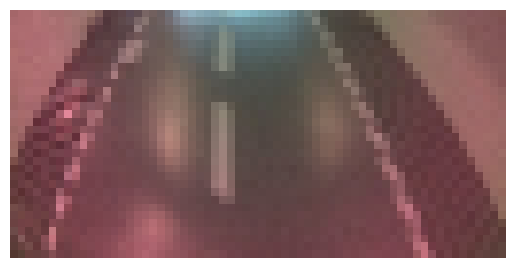

Label: [[0.11 0.29]]
Prediction: [[0.18032339 0.08337174]]


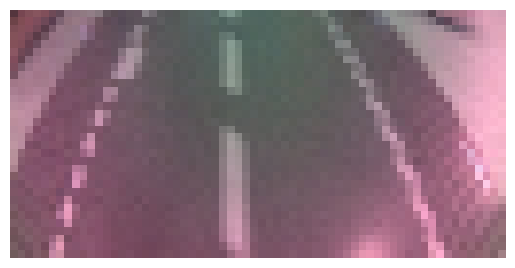

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18182108 0.08168808]]


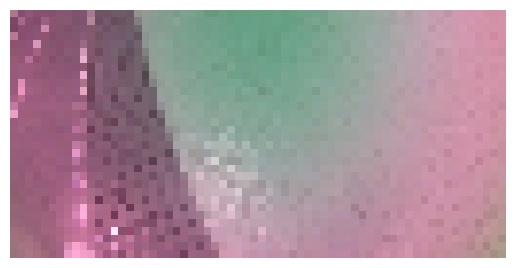

Label: [[0.11 0.29]]
Prediction: [[0.17265005 0.08793651]]


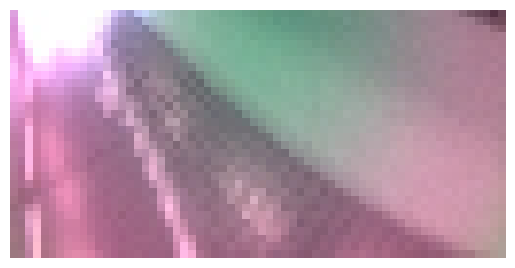

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18704876 0.0807724 ]]


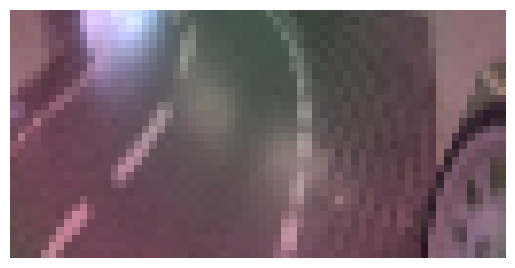

Label: [[0.20000137 0.19999863]]
Prediction: [[0.18787074 0.08294257]]


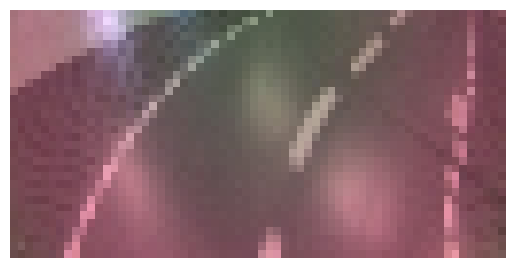

In [ ]:
model = tf.keras.models.load_model('100epochs.keras')

test_ds = load_dataset(test_data, augment=False)
model.evaluate(test_ds)

for frame in test_data:
    img, label = load_dataset([frame], augment=False).take(1).get_single_element()
    print(f"Label: {label.numpy()}")
    print(f"Prediction: {model(img, training=False).numpy()}")
    imshow(img[0].numpy())

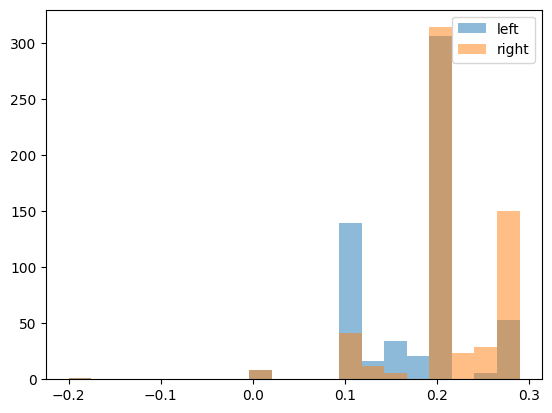

In [ ]:
import matplotlib.pyplot as plt
lefts = [f['left_wheel'] for f in train_data]
rights = [f['right_wheel'] for f in train_data]
plt.hist(lefts, bins=20, alpha=0.5, label='left')
plt.hist(rights, bins=20, alpha=0.5, label='right')
plt.legend(); plt.show()